In [ ]:
############################################
# SABIA : Gestão de competências ML   #
############################################

In [2]:
# Bibliotecas 
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [3]:
# Carregar tabelas originais 

# Dimensão 
dim_comp = pd.read_csv ("competencia_postgres_tratado.csv")
dim_colab = pd.read_csv ("dc_DadosPrimarios_tratado.csv")
dim_soft = pd.read_csv ("dim_Softskills.csv")
dim_trei = pd.read_csv ("dim_Treinamentos.csv")
dim_empr = pd.read_csv ("empresa_postgres_tratado.csv")
dim_serv = pd.read_csv ("servicos_postgres_tratado.csv")

# Fato
colab_comp = pd.read_csv ("fato_colaborador_competencia.csv")
empr_serv = pd.read_csv ("fato_Empresa_Servico.csv")
serv_comp = pd.read_csv ("fato_servico_competencia.csv")
soft_colab = pd.read_csv ("fato_Softskills.csv")
trein_colab = pd.read_csv ("fato_Treinamentos.csv")
colab_empr = pd.read_csv ("colaborador_empresa_postgres_tratado.csv")

In [ ]:
## Preparar as tabelas para os modelos. Removi todas as colunas irrelevantes para facilitar o processo de análise 

# Competências
competencias = dim_comp.drop(
    columns=["Descricao", "Nivel_Competencia"],
    errors="ignore"
)

# Colaboradores 
colaboradores = dim_colab.drop(
    columns=["Email","CPF","Data de Nascimento","Telefone","Estado","Endereço","Telefone_status","Situacao_CPF","idCidade","idData_Admissao"],
    errors="ignore"
)

# Empresas
empresa = dim_empr.drop(
    columns=["Cnpj_Empresa","Contato_Empresa","Setor_Empresa","Logradouro",	"Numero",	"Estado",	"Status_Telefone",	"Status_Cnpj"],
    errors="ignore"
)

#Serviços 
servicos = dim_serv.drop(
    columns=["Data_Servico", "Descricao_Servico"],
    errors="ignore"
)

# Colab_comp
colaborador_competencia = colab_comp.drop(
    columns=["id"],
    errors="ignore"
)

In [5]:
# Verificar: 
display(competencias)
display(colaboradores)
display(empresa)
display(servicos)
display(colaborador_competencia)

,Id_Competencia,Nome_Competencia
0,1,Python
1,2,SQL
2,3,C#
3,4,Arquitetura de Software
4,5,Metodologias Ágeis
5,6,React
6,7,Análise de Dados
7,8,Gestão de Projetos
8,9,Segurança da Informação


,idColaborador,Nome
0,7,Vanessa Nogueira
1,8,Eduardo Araújo
2,9,Mariana Silva
3,10,Rafael Costa
4,11,Thiago Moura
...,...,...
75,76,Carla Martins
76,77,Roberto Dias
77,78,Larissa Costa
78,79,Ricardo Almeida


,Id_Empresa,Nome_Empresa
0,1,Alfa
1,2,Beta
2,3,Gama
3,4,Tech Soluções
4,5,Inova Sistemas
5,6,Data Insights
6,7,Global Soft
7,8,NextGen Tech
8,9,RS Sistemas
9,10,SC Tecnologia


,Id_Servico,Nome_Servico
0,1,Manutenção
1,2,Atualização
2,3,Implantação
3,4,Serviço Errado
4,5,Auditoria
5,6,Desenvolvimento
6,7,Treinamento
7,8,Consultoria


,idColaborador,Id_Competencia
0,1,2
1,1,7
2,1,9
3,2,1
4,2,4
...,...,...
128,78,5
129,79,6
130,80,2
131,80,3


In [ ]:
# Para rodar as análises de cluster, precisa das tabelas com a seguinte estrutura: 

# Colaboradores (colaboradores): idColaborador, Nome, Id_Empresa
display(colaboradores)

,idColaborador,Nome
0,7,Vanessa Nogueira
1,8,Eduardo Araújo
2,9,Mariana Silva
3,10,Rafael Costa
4,11,Thiago Moura
...,...,...
75,76,Carla Martins
76,77,Roberto Dias
77,78,Larissa Costa
78,79,Ricardo Almeida


In [7]:
# Fazer um merge das tabelas: 

# Colaboradores: idColaborador, Nome, Id_Empresa
colaboradores2 = colaboradores.merge(
    colab_empr[['idColaborador', 'Id_Empresa']],
    on='idColaborador',
    how='left'
).merge(
    empresa,
    on='Id_Empresa',
    how='left'
)

# Remover coluna Nome_Empresa
colaboradores2 = colaboradores2.drop('Nome_Empresa', axis=1)

display(colaboradores2)

,idColaborador,Nome,Id_Empresa
0,7,Vanessa Nogueira,2
1,8,Eduardo Araújo,11
2,9,Mariana Silva,3
3,10,Rafael Costa,3
4,11,Thiago Moura,11
...,...,...,...
75,76,Carla Martins,11
76,77,Roberto Dias,11
77,78,Larissa Costa,11
78,79,Ricardo Almeida,11


In [8]:
# Empresas (empresa): Id_Empresa, Nome_Empresa
display(empresa)

,Id_Empresa,Nome_Empresa
0,1,Alfa
1,2,Beta
2,3,Gama
3,4,Tech Soluções
4,5,Inova Sistemas
5,6,Data Insights
6,7,Global Soft
7,8,NextGen Tech
8,9,RS Sistemas
9,10,SC Tecnologia


In [9]:
# Competências (competencias): Id_Competencia, Nome_Competencia
display(competencias)

,Id_Competencia,Nome_Competencia
0,1,Python
1,2,SQL
2,3,C#
3,4,Arquitetura de Software
4,5,Metodologias Ágeis
5,6,React
6,7,Análise de Dados
7,8,Gestão de Projetos
8,9,Segurança da Informação


In [10]:
# Colaborador ↔ Competencias (colab_comp): idColaborador, Id_Competencia
display(colaborador_competencia)

,idColaborador,Id_Competencia
0,1,2
1,1,7
2,1,9
3,2,1
4,2,4
...,...,...
128,78,5
129,79,6
130,80,2
131,80,3


In [11]:
# Soft Skills (dim_soft): idSoft_Skills, Nome_SoftSkill
display(dim_soft)

,idSoft_Skills,Soft_Skills
0,1,Foco em resultados
1,2,Resiliência
2,3,Capacidade de liderança
3,4,Aprendizado contínuo
4,5,Colaboração
5,6,Visão sistêmica
6,7,Trabalho interdisciplinar
7,8,Proatividade
8,9,Autonomia
9,10,Responsabilidade


In [12]:
# Colaborador ↔ Soft Skills (soft_colab): idColaborador, idSoft_Skills
display(soft_colab)

,idColaborador,idSoft_Skills
0,1,1
1,1,2
2,1,3
3,1,4
4,1,5
...,...,...
279,79,15
280,79,3
281,80,21
282,80,2


In [13]:
# Treinamentos (dim_trei): idTreinamentos_Realizados, Nome_Treinamento
display(dim_trei)

,idTreinamentos_Realizados,Treinamentos_Realizados
0,1,Excel Avançado
1,2,Segurança da Informação
2,3,Scrum Foundation
3,4,Desenvolvimento Web com React
4,5,Curso de Power BI


In [14]:
# Colaborador ↔ Treinamentos (trein_colab): idColaborador, idTreinamentos_Realizados
display(trein_colab)

,idColaborador,idTreinamentos_Realizados
0,7,1
1,7,2
2,8,2
3,9,3
4,10,4
...,...,...
147,78,3
148,79,5
149,80,4
150,80,2


In [15]:
# Serviços (servicos): Id_Servico, Nome_Servico
display(servicos)

,Id_Servico,Nome_Servico
0,1,Manutenção
1,2,Atualização
2,3,Implantação
3,4,Serviço Errado
4,5,Auditoria
5,6,Desenvolvimento
6,7,Treinamento
7,8,Consultoria


In [16]:
# Serviço ↔ Competências (serv_comp): Id_Servico, Id_Competencia
display(serv_comp)

,Id_Servico,Id_Competencia
0,1,2
1,1,4
2,1,9
3,2,1
4,2,2
5,2,5
6,3,3
7,3,4
8,3,6
9,4,8


In [17]:
# Para fazer o cluster, é preciso criar uma matriz de presença/ ausência a partir da criação de uma coluna binária

# 1. Hard skills
colab_hard = colaborador_competencia.merge(competencias, on="Id_Competencia")
colab_hard["valor"] = 1
mat_hard = colab_hard.pivot_table(
    index="idColaborador",
    columns="Nome_Competencia",
    values="valor",
    fill_value=0
)

display(colab_hard)

,idColaborador,Id_Competencia,Nome_Competencia,valor
0,1,2,SQL,1
1,1,7,Análise de Dados,1
2,1,9,Segurança da Informação,1
3,2,1,Python,1
4,2,4,Arquitetura de Software,1
...,...,...,...,...
128,78,5,Metodologias Ágeis,1
129,79,6,React,1
130,80,2,SQL,1
131,80,3,C#,1


In [18]:
# Matriz binária hard skills
mat_hard = colab_hard[['idColaborador','Nome_Competencia']].drop_duplicates()
mat_hard['valor'] = 1
mat_hard = mat_hard.pivot(index='idColaborador', columns='Nome_Competencia', values='valor').fillna(0)

# Estatísticas básicas
mat_hard['Total_Hard'] = mat_hard.sum(axis=1)
display(mat_hard)

Nome_Competencia,Análise de Dados,Arquitetura de Software,C#,Gestão de Projetos,Metodologias Ágeis,Python,React,SQL,Segurança da Informação,Total_Hard
idColaborador,,,,,,,,,,
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0
5,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...
76,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
77,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
78,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0


In [19]:
# 2. Soft skills
colab_soft = soft_colab.merge(dim_soft, left_on="idSoft_Skills", right_on="idSoft_Skills")
colab_soft["valor"] = 1
mat_soft = colab_soft.pivot_table(
    index="idColaborador",
    columns="Soft_Skills",
    values="valor",
    fill_value=0
)

display(colab_soft)

,idColaborador,idSoft_Skills,Soft_Skills,valor
0,1,1,Foco em resultados,1
1,1,2,Resiliência,1
2,1,3,Capacidade de liderança,1
3,1,4,Aprendizado contínuo,1
4,1,5,Colaboração,1
...,...,...,...,...
279,79,15,Adaptabilidade,1
280,79,3,Capacidade de liderança,1
281,80,21,Dar e receber feedback,1
282,80,2,Resiliência,1


In [20]:
# Matriz binária soft skills
mat_soft = colab_soft[['idColaborador','Soft_Skills']].drop_duplicates()
mat_soft['valor'] = 1
mat_soft = mat_soft.pivot(index='idColaborador', columns='Soft_Skills', values='valor').fillna(0)

# Estatísticas básicas
mat_soft['Total_Soft'] = mat_soft.sum(axis=1)
display(mat_soft)

Soft_Skills,Adaptabilidade,Aprendizado contínuo,Atenção aos detalhes,Autonomia,Capacidade de liderança,Colaboração,Criatividade,Curiosidade,Dar e receber feedback,Empatia,...,Pensamento analítico,Pensamento crítico,Proatividade,Resiliência,Resolução de problemas,Responsabilidade,Trabalho interdisciplinar,Visão sistêmica,Ética profissional,Total_Soft
idColaborador,,,,,,,,,,,,,,,,,,,,,
1,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,5.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,5.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
5,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
77,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0
78,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0


In [21]:
# 3.Treinamentos
colab_trei = trein_colab.merge(dim_trei, left_on="idTreinamentos_Realizados", right_on="idTreinamentos_Realizados")
colab_trei["valor"] = 1
mat_trei = colab_trei.pivot_table(
    index="idColaborador",
    columns="Treinamentos_Realizados",
    values="valor",
    fill_value=0
)

display(colab_trei)


,idColaborador,idTreinamentos_Realizados,Treinamentos_Realizados,valor
0,7,1,Excel Avançado,1
1,7,2,Segurança da Informação,1
2,8,2,Segurança da Informação,1
3,9,3,Scrum Foundation,1
4,10,4,Desenvolvimento Web com React,1
...,...,...,...,...
147,78,3,Scrum Foundation,1
148,79,5,Curso de Power BI,1
149,80,4,Desenvolvimento Web com React,1
150,80,2,Segurança da Informação,1


In [22]:
# Matriz binária treinamentos
mat_trei = colab_trei[['idColaborador','Treinamentos_Realizados']].drop_duplicates()
mat_trei['valor'] = 1
mat_trei = mat_trei.pivot(index='idColaborador', columns='Treinamentos_Realizados', values='valor').fillna(0)

# Estatísticas básicas
mat_trei['Total_Treinamentos'] = mat_trei.sum(axis=1)
display(mat_trei)

Treinamentos_Realizados,Curso de Power BI,Desenvolvimento Web com React,Excel Avançado,Scrum Foundation,Segurança da Informação,Total_Treinamentos
idColaborador,,,,,,
1,1.0,1.0,1.0,0.0,0.0,3.0
2,0.0,0.0,1.0,0.0,1.0,2.0
3,0.0,0.0,1.0,1.0,0.0,2.0
4,0.0,1.0,0.0,0.0,0.0,1.0
5,0.0,1.0,0.0,1.0,1.0,3.0
...,...,...,...,...,...,...
76,0.0,0.0,1.0,0.0,1.0,2.0
77,0.0,0.0,0.0,0.0,1.0,1.0
78,1.0,0.0,0.0,1.0,1.0,3.0


In [23]:
## Pacotes para realizar a PCA e clusterização (K-mean)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Hard skills 

#Matriz binária sem duplicados - aqui removo qq duplicata para ter certeza que o valor não está inflacionado
mat_hard = colab_hard[['idColaborador','Nome_Competencia']].drop_duplicates()
mat_hard['valor'] = 1
mat_hard = mat_hard.pivot(index='idColaborador', columns='Nome_Competencia', values='valor').fillna(0)

In [25]:
# PCA (análise de componentes principais): para reduzir a dimensionalidade da matriz de hard skills 
# Útil para visualizar padrões entre colaboradores em um espaço bidimensional (e não multidimensional)

scaler = StandardScaler()
hard_scaled = scaler.fit_transform(mat_hard)
pca = PCA(n_components=2)
hard_pca = pca.fit_transform(hard_scaled)
mat_hard['PCA1'] = hard_pca[:,0]
mat_hard['PCA2'] = hard_pca[:,1]

In [26]:
# Clusterização

# Aqui usei a função no modelo default. O número de cluster = 4 (analítico, generalista, programador, sênior) - essa métrica é ajustável 
# random_state = 42 - também é ajustável porém por convenção foi escolhido esse número para análise exploratória. 

kmeans = KMeans(n_clusters=4, random_state=42)
mat_hard['Cluster'] = kmeans.fit_predict(hard_scaled)

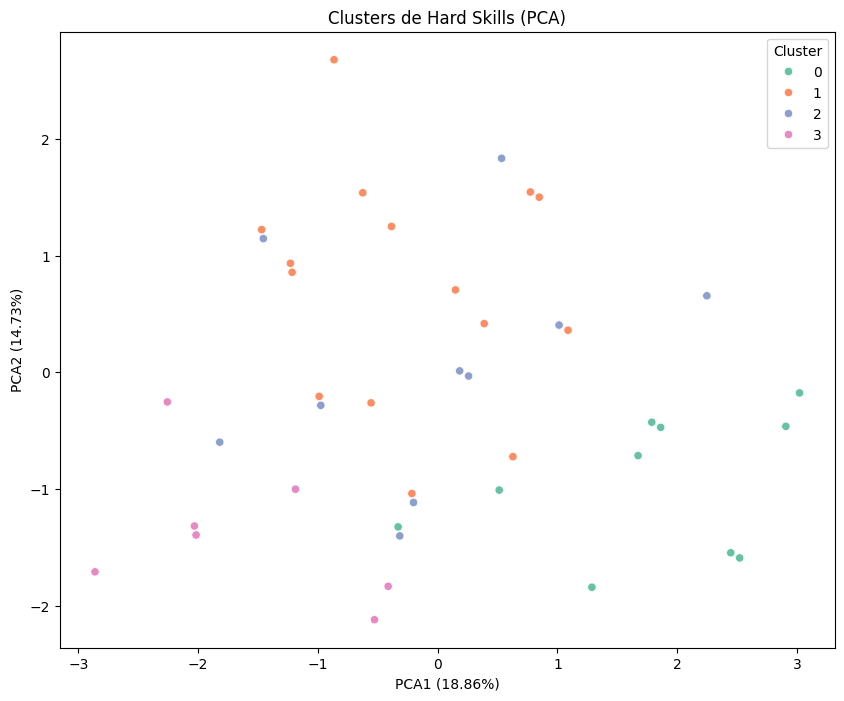

In [27]:
# Variância explicada
explained_var = pca.explained_variance_ratio_ * 100

# Scatterplot
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=mat_hard,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2'
)
plt.xlabel(f"PCA1 ({explained_var[0]:.2f}%)")
plt.ylabel(f"PCA2 ({explained_var[1]:.2f}%)")
plt.title("Clusters de Hard Skills (PCA)")
plt.show()

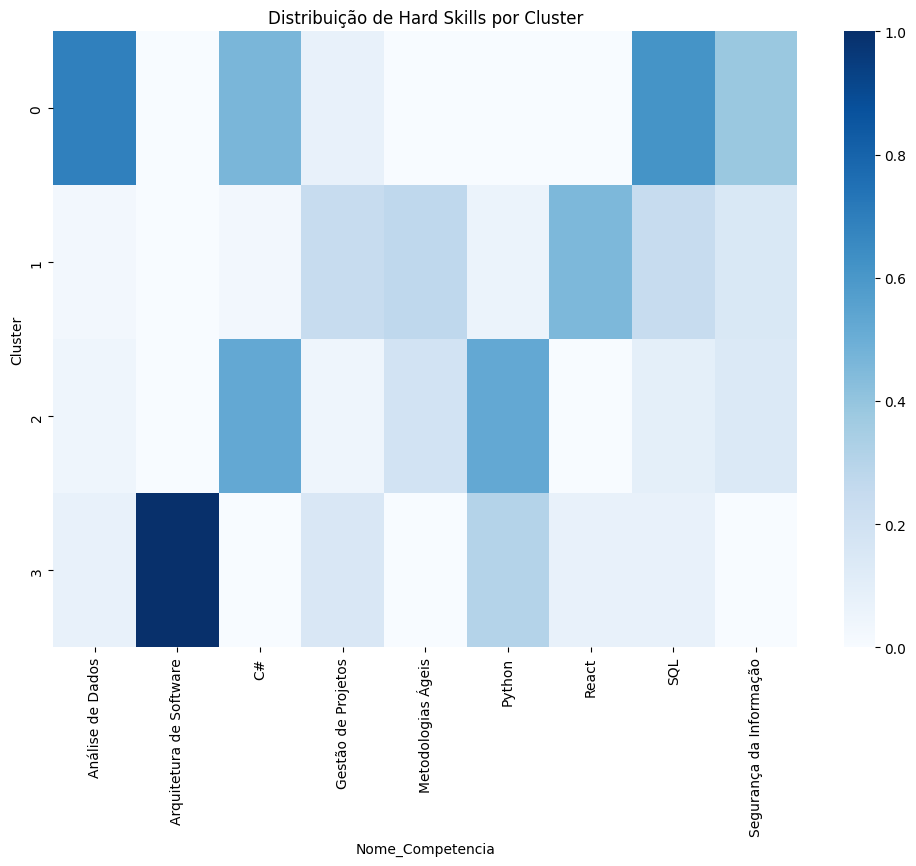

In [28]:
# Heatmap por cluster - quanto mais próximo de 1, mais frequente a skill é dentro do cluster 
cluster_mean = mat_hard.groupby('Cluster').mean().drop(['PCA1','PCA2'], axis=1)
plt.figure(figsize=(12,8))
sns.heatmap(cluster_mean, cmap='Blues')
plt.title("Distribuição de Hard Skills por Cluster")
plt.show()

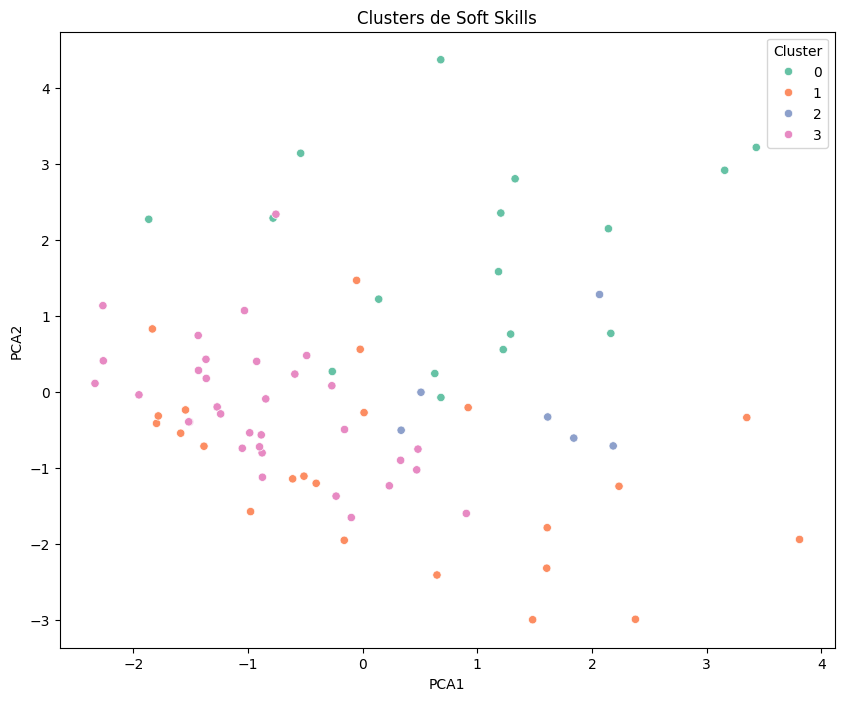

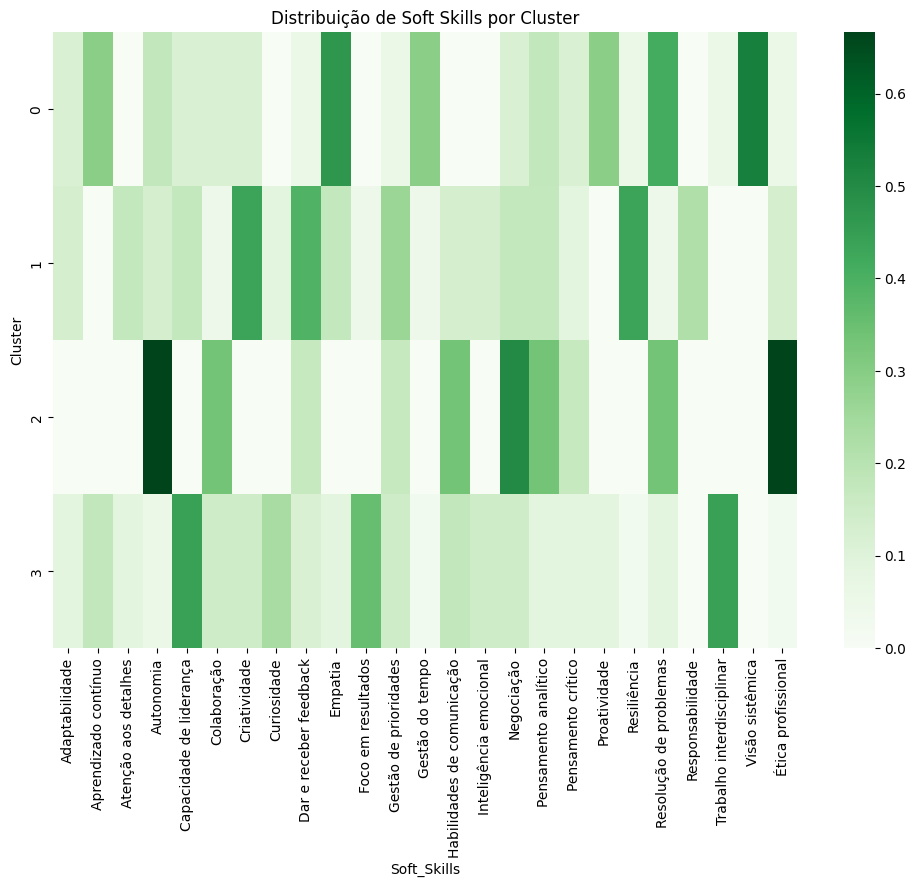

In [29]:
# Soft skills 

# Matriz binária sem duplicados
mat_soft = colab_soft[['idColaborador','Soft_Skills']].drop_duplicates()
mat_soft['valor'] = 1
mat_soft = mat_soft.pivot(index='idColaborador', columns='Soft_Skills', values='valor').fillna(0)

# PCA
soft_scaled = scaler.fit_transform(mat_soft)
soft_pca = pca.fit_transform(soft_scaled)
mat_soft['PCA1'] = soft_pca[:,0]
mat_soft['PCA2'] = soft_pca[:,1]

# Clusterização
mat_soft['Cluster'] = kmeans.fit_predict(soft_scaled)

# Plot PCA
plt.figure(figsize=(10,8))
sns.scatterplot(data=mat_soft, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title("Clusters de Soft Skills")
plt.show()

# Heatmap por cluster
cluster_mean_soft = mat_soft.groupby('Cluster').mean().drop(['PCA1','PCA2'], axis=1)
plt.figure(figsize=(12,8))
sns.heatmap(cluster_mean_soft, cmap='Greens')
plt.title("Distribuição de Soft Skills por Cluster")
plt.show()

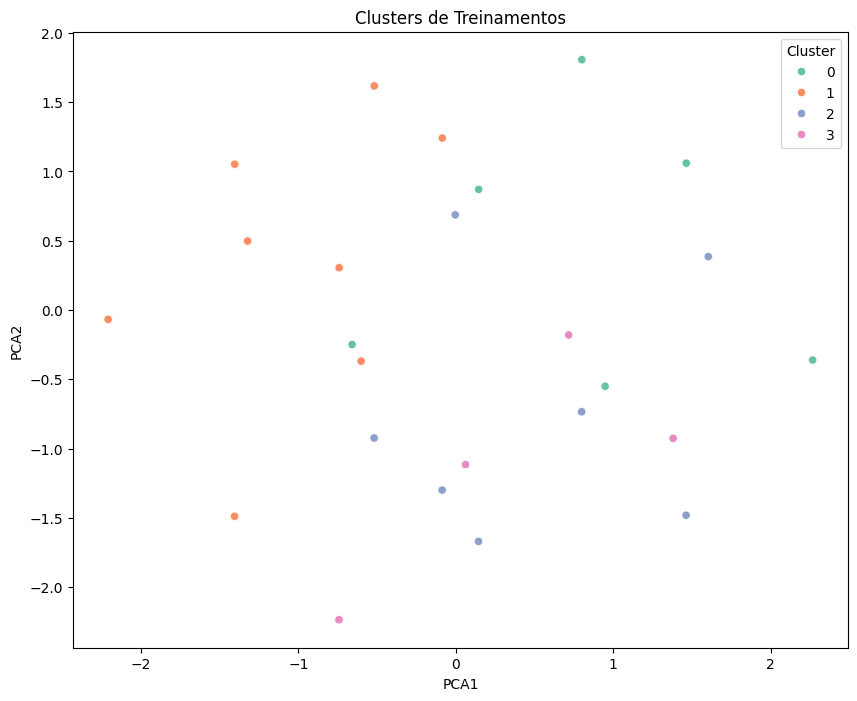

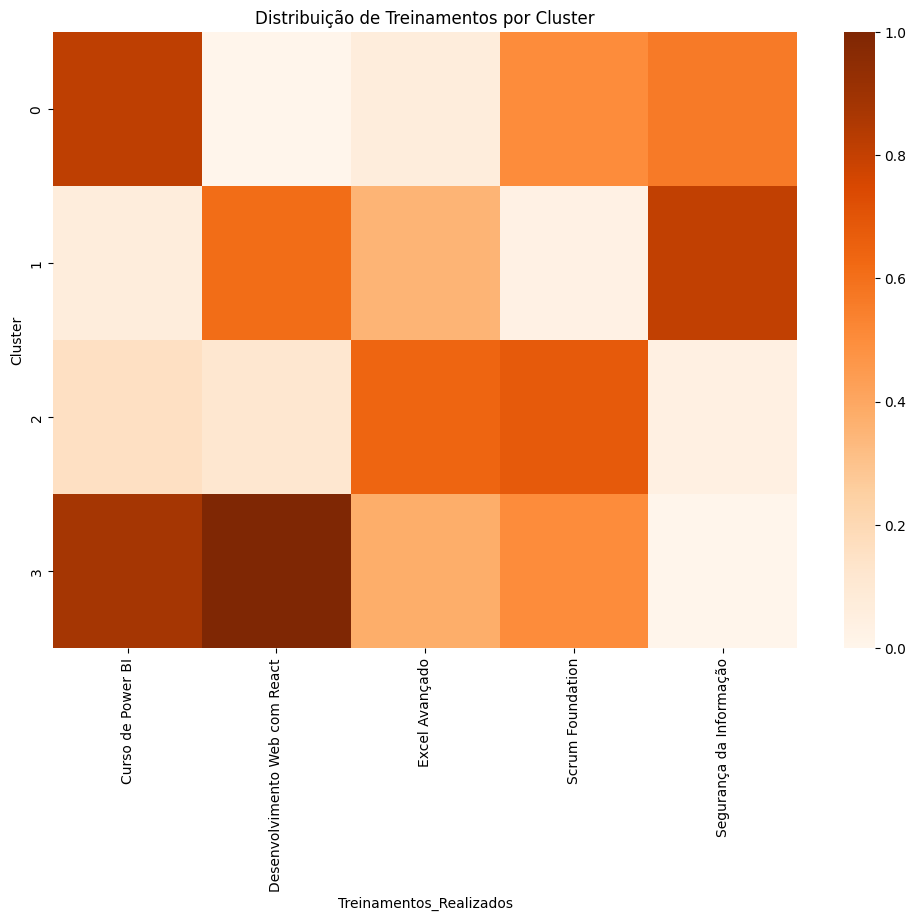

In [30]:
# Treinamentos

# Matriz binária sem duplicados
mat_trei = colab_trei[['idColaborador','Treinamentos_Realizados']].drop_duplicates()
mat_trei['valor'] = 1
mat_trei = mat_trei.pivot(index='idColaborador', columns='Treinamentos_Realizados', values='valor').fillna(0)

# PCA
trei_scaled = scaler.fit_transform(mat_trei)
trei_pca = pca.fit_transform(trei_scaled)
mat_trei['PCA1'] = trei_pca[:,0]
mat_trei['PCA2'] = trei_pca[:,1]

# Clusterização
mat_trei['Cluster'] = kmeans.fit_predict(trei_scaled)

# Plot PCA
plt.figure(figsize=(10,8))
sns.scatterplot(data=mat_trei, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title("Clusters de Treinamentos")
plt.show()

# Heatmap por cluster
cluster_mean_trei = mat_trei.groupby('Cluster').mean().drop(['PCA1','PCA2'], axis=1)
plt.figure(figsize=(12,8))
sns.heatmap(cluster_mean_trei, cmap='Oranges')
plt.title("Distribuição de Treinamentos por Cluster")
plt.show()

Cluster,0,1,2,3
Id_Empresa,,,,
1,1,1,0,2
2,0,2,2,0
3,0,1,3,0
4,2,2,0,0
5,1,1,1,1
6,0,1,2,1
7,1,2,1,0
8,0,0,2,2
9,0,2,2,0


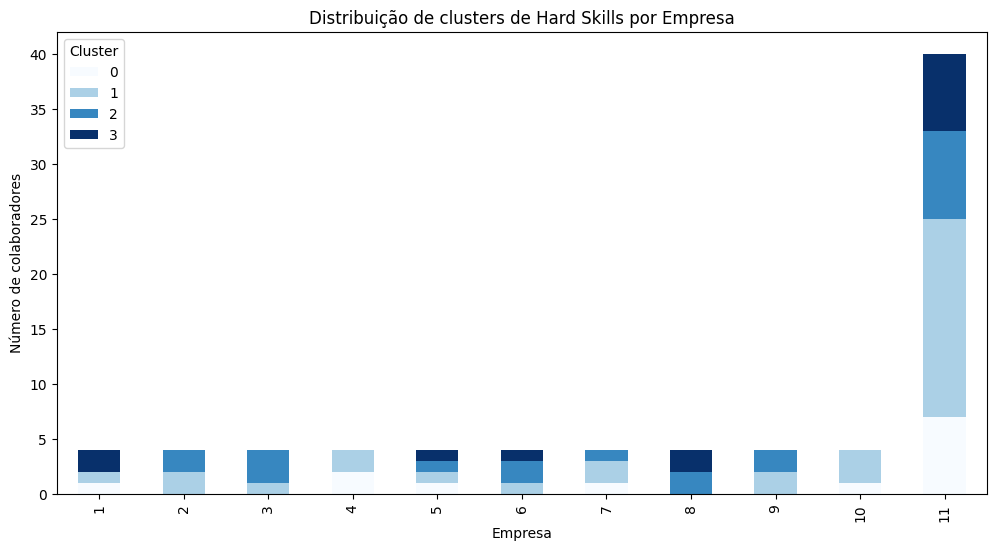

In [31]:
#  Quantidade de colaboradores em cada cluster de hard skills por empresa, usando um gráfico de barras empilhadas

# Adicionar empresa aos dados de hard skills
hard_empresa = mat_hard.merge(
    colaboradores2[['idColaborador','Id_Empresa']], 
    left_index=True, right_on='idColaborador'
)

# Contagem de colaboradores por cluster e empresa
hard_cluster_empresa = hard_empresa.groupby(['Id_Empresa','Cluster']).size().unstack(fill_value=0)
display(hard_cluster_empresa)

# Plot barras empilhadas
hard_cluster_empresa.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Blues')
plt.title("Distribuição de clusters de Hard Skills por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Número de colaboradores")
plt.show()

Cluster,0,1,2,3
Id_Empresa,,,,
1,1,2,1,0
2,2,2,0,0
3,1,1,1,1
4,0,0,1,3
5,0,1,0,3
6,0,2,0,2
7,1,2,0,1
8,0,3,1,0
9,3,1,0,0


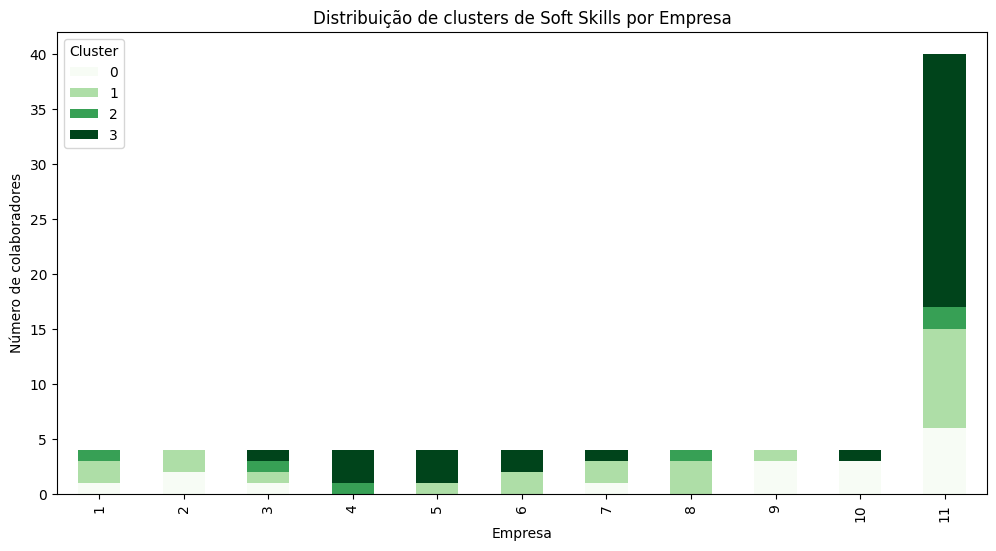

In [32]:
# Adicionar empresa aos dados de soft skills
soft_empresa = mat_soft.merge(
    colaboradores2[['idColaborador','Id_Empresa']], 
    left_index=True, right_on='idColaborador'
)

# Contagem de colaboradores por cluster e empresa
soft_cluster_empresa = soft_empresa.groupby(['Id_Empresa','Cluster']).size().unstack(fill_value=0)
display(soft_cluster_empresa)

# Plot barras empilhadas
soft_cluster_empresa.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Greens')
plt.title("Distribuição de clusters de Soft Skills por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Número de colaboradores")
plt.show()

Cluster,0,1,2,3
Id_Empresa,,,,
1,0,3,1,0
2,0,4,0,0
3,1,1,2,0
4,0,1,3,0
5,2,1,1,0
6,1,1,1,1
7,0,3,1,0
8,2,1,1,0
9,0,1,2,1


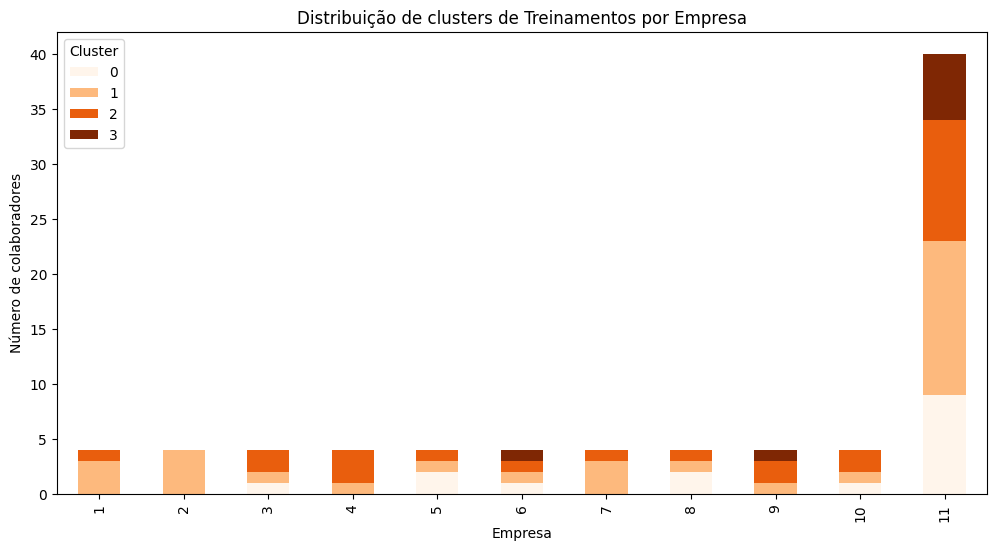

In [33]:
# Adicionar empresa aos dados de treinamentos
trei_empresa = mat_trei.merge(
    colaboradores2[['idColaborador','Id_Empresa']], 
    left_index=True, right_on='idColaborador'
)

# Contagem de colaboradores por cluster e empresa
trei_cluster_empresa = trei_empresa.groupby(['Id_Empresa','Cluster']).size().unstack(fill_value=0)
display(trei_cluster_empresa)

# Plot barras empilhadas
trei_cluster_empresa.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Oranges')
plt.title("Distribuição de clusters de Treinamentos por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Número de colaboradores")
plt.show()

In [34]:
# Criar matriz binária para hard e soft skills 

# Matriz binária Hard Skills
mat_hard = colab_hard[['idColaborador','Nome_Competencia']].drop_duplicates()
mat_hard['valor'] = 1
mat_hard = mat_hard.pivot(index='idColaborador', columns='Nome_Competencia', values='valor').fillna(0)

# Matriz binária Soft Skills
mat_soft = colab_soft[['idColaborador','Soft_Skills']].drop_duplicates()
mat_soft['valor'] = 1
mat_soft = mat_soft.pivot(index='idColaborador', columns='Soft_Skills', values='valor').fillna(0)

In [35]:
df_corr = pd.DataFrame({
    'Total_Hard': mat_hard.sum(axis=1),
    'Total_Soft': mat_soft.sum(axis=1)
})

In [36]:
df_corr['Perc_Hard'] = df_corr['Total_Hard'] / df_corr['Total_Hard'].max()
df_corr['Perc_Soft'] = df_corr['Total_Soft'] / df_corr['Total_Soft'].max()

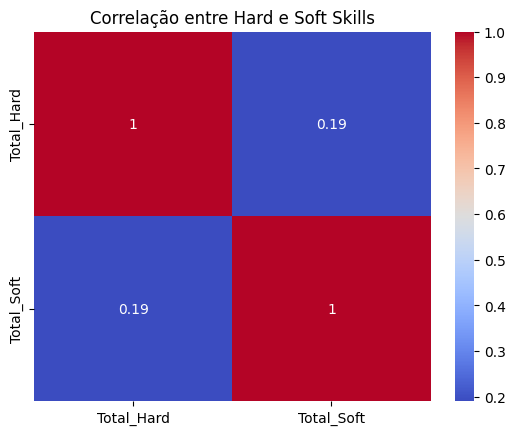

In [37]:
corr_matrix = df_corr[['Total_Hard','Total_Soft']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlação entre Hard e Soft Skills")
plt.show()

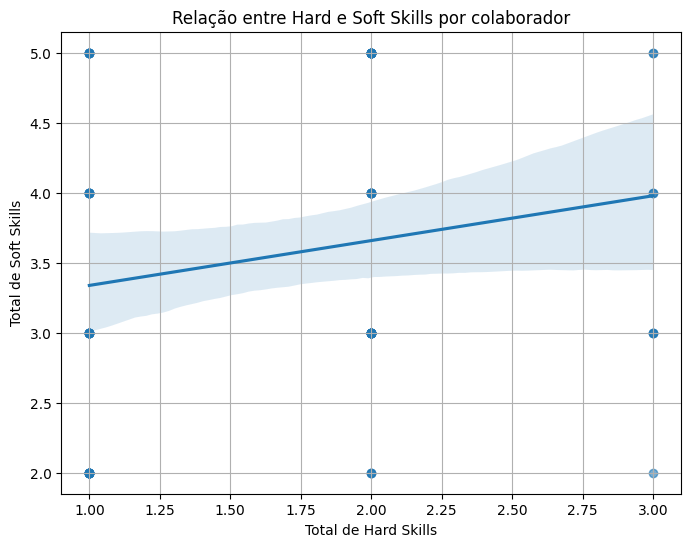

In [38]:
plt.figure(figsize=(8,6))
sns.regplot(x='Total_Hard', y='Total_Soft', data=df_corr, scatter_kws={'alpha':0.6})
plt.xlabel("Total de Hard Skills")
plt.ylabel("Total de Soft Skills")
plt.title("Relação entre Hard e Soft Skills por colaborador")
plt.grid(True)
plt.show()

## Fim da clusterização ## 

In [39]:
## Correlação de Pearson - calcula a correlação linear entre variáveis (nesse caso, soft e hard skills)
 
from scipy.stats import pearsonr
import numpy as np

# Preparar matrizes
hard_cols = mat_hard.columns
soft_cols = mat_soft.columns

# Criar DataFrame para armazenar p-values
p_values = pd.DataFrame(index=hard_cols, columns=soft_cols)

# Calcular p-value para cada par Hard x Soft
for h in hard_cols:
    for s in soft_cols:
        r, p = pearsonr(mat_hard[h], mat_soft[s])
        p_values.loc[h, s] = p

display(p_values)

Soft_Skills,Adaptabilidade,Aprendizado contínuo,Atenção aos detalhes,Autonomia,Capacidade de liderança,Colaboração,Criatividade,Curiosidade,Dar e receber feedback,Empatia,...,Negociação,Pensamento analítico,Pensamento crítico,Proatividade,Resiliência,Resolução de problemas,Responsabilidade,Trabalho interdisciplinar,Visão sistêmica,Ética profissional
Nome_Competencia,,,,,,,,,,,,,,,,,,,,,
Análise de Dados,0.215401,0.754039,0.95651,0.298656,0.419557,0.159506,0.734504,0.641031,0.164406,0.322123,...,0.935355,0.489228,0.410153,0.837194,0.0046,0.966682,0.108558,0.643654,0.185452,0.185452
Arquitetura de Software,0.485731,0.291869,0.227638,0.379209,0.779687,0.735092,0.862494,0.572547,0.667089,0.230259,...,0.829048,0.379209,0.193714,0.485731,0.426471,0.927518,0.817238,0.765412,0.662196,0.014617
C#,0.48152,0.687717,0.591438,0.605114,0.663932,0.317675,0.594762,0.549632,0.351878,0.800083,...,0.917141,0.605114,0.860529,0.00389,0.824749,0.508165,0.891748,0.355023,0.391516,0.983365
Gestão de Projetos,0.410153,0.560345,0.250107,0.0046,0.551143,0.641031,0.051825,0.641031,0.553275,0.322123,...,0.120406,0.298656,0.410153,0.837194,0.117378,0.966682,0.338212,0.75787,0.525567,0.185452
Metodologias Ágeis,0.765412,0.494508,0.361262,0.100333,0.280003,0.572547,0.365592,0.572547,0.738018,0.047333,...,0.568839,0.426471,0.485731,0.193714,0.426471,0.00003,0.315129,0.230636,0.014617,0.611566
Python,0.52969,0.792015,0.625352,0.272806,0.129334,0.017244,0.686959,0.35885,0.128792,0.897173,...,0.985879,0.061965,0.52969,0.787877,0.061965,0.577825,0.944625,0.787877,0.940618,0.940618
React,0.196788,0.873049,0.696807,0.75787,0.25843,0.093177,0.280108,1.0,0.480201,1.0,...,0.562011,0.643654,0.139513,0.139513,0.278928,0.29476,0.253741,0.890586,0.861749,0.861749
SQL,0.436989,0.645343,0.218697,0.53768,0.551345,0.624793,0.195336,0.280513,0.771868,0.70927,...,0.365929,0.913493,0.341636,0.931308,0.001941,0.445027,0.202218,0.897118,0.910402,0.350549
Segurança da Informação,0.765412,0.853946,0.884582,0.966682,0.779687,0.735092,0.862494,0.029633,0.047333,0.27006,...,0.071103,0.100333,0.485731,0.193714,0.379209,0.3671,0.140577,0.765412,0.662196,0.164754


In [40]:
# Correlação entre hard x soft skill

# 1. Preparar as matrizes para o heatmap

# Remover colunas de total, se existirem
mat_hard_clean = mat_hard.drop(columns=['Total_Hard'], errors='ignore')
mat_soft_clean = mat_soft.drop(columns=['Total_Soft'], errors='ignore')

# Garantir que os índices são idColaborador
mat_hard_clean.index.name = 'idColaborador'
mat_soft_clean.index.name = 'idColaborador'

In [41]:
# 2. Alinhar matrizes pelo idColaborador
mat_merged = mat_hard_clean.merge(
    mat_soft_clean, 
    left_index=True, 
    right_index=True, 
    suffixes=('_Hard', '_Soft')
)

In [42]:
# 3. Listar colunas de cada tipo
hard_cols = mat_hard_clean.columns.tolist()
soft_cols = mat_soft_clean.columns.tolist()

In [43]:
# 4. Criar matriz de correlação cruzada
corr_matrix = pd.DataFrame(
    index=soft_cols,
    columns=hard_cols,
    data=[[mat_merged[s].corr(mat_merged[h]) for h in hard_cols] for s in soft_cols]
)

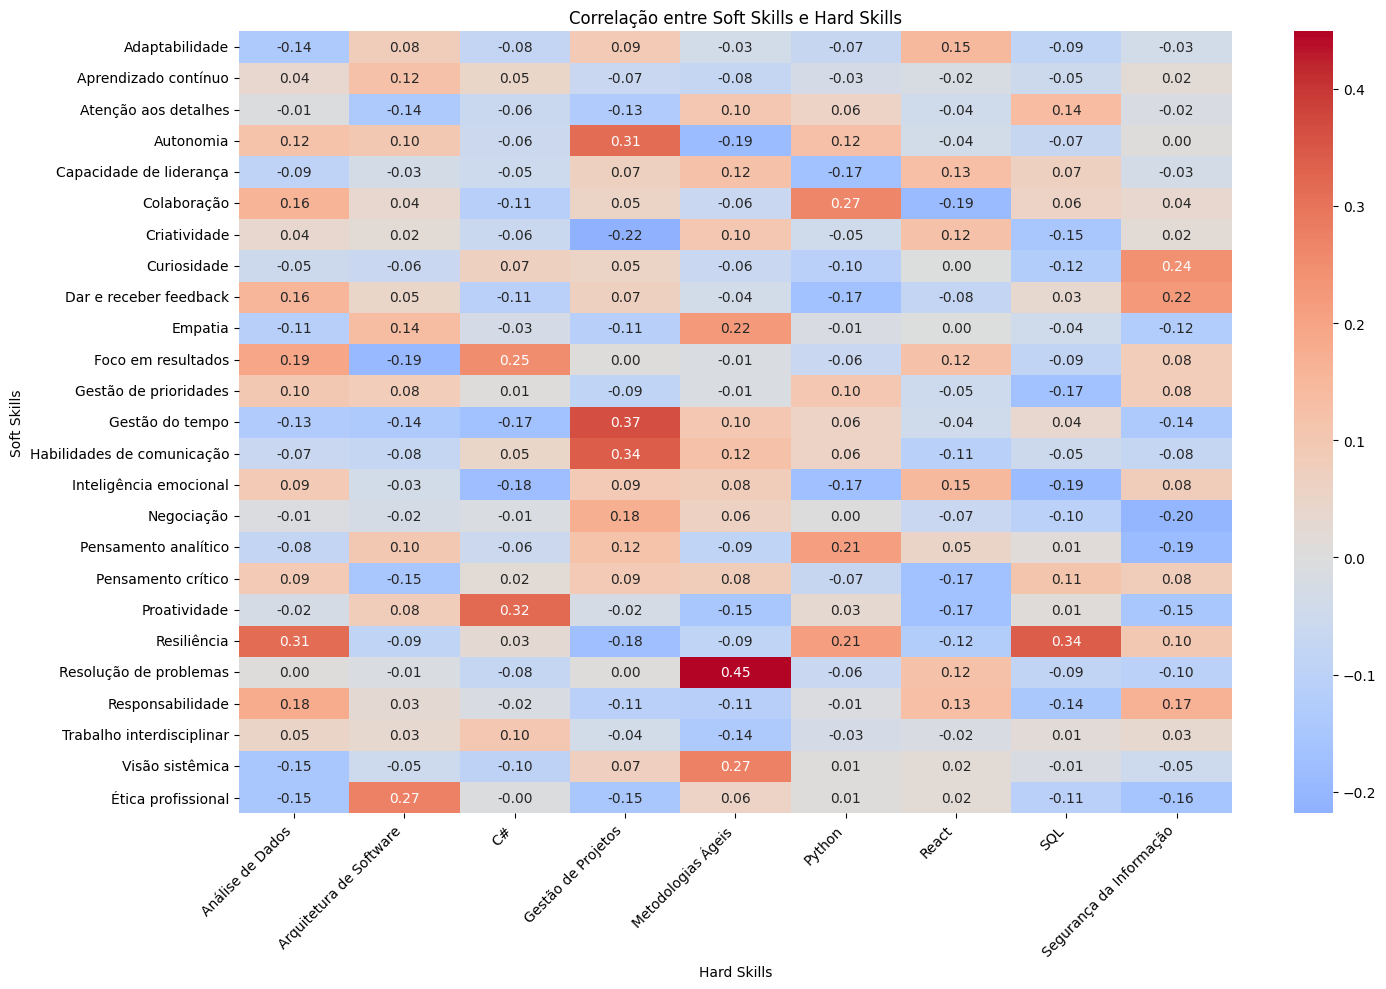

In [44]:
# 5. Visualizar heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Correlação entre Soft Skills e Hard Skills")
plt.xlabel("Hard Skills")
plt.ylabel("Soft Skills")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Fim da correlação ##

In [45]:
######### 
#
# Calcular os gaps entre colaborador x competência x empresa

# 1. Merge Empresa x Serviço com Serviço x Competência
emp_comp = empr_serv.merge(serv_comp, on='Id_Servico', how='left')

# Agora temos: Id_Empresa, Id_Servico, Id_Competencia
emp_comp.head()

,Id_Empresa,Id_Servico,Id_Competencia
0,1,1,2
1,1,1,4
2,1,1,9
3,1,2,1
4,1,2,2


In [46]:
# Colaborador x Competência
colab_comp = colaborador_competencia.copy()

# Merge para saber empresa do colaborador
colab_comp = colab_comp.merge(colaboradores2[['idColaborador','Id_Empresa']], on='idColaborador', how='left')

colab_comp.head(10)

,idColaborador,Id_Competencia,Id_Empresa
0,1,2,11
1,1,7,11
2,1,9,11
3,2,1,1
4,2,4,1
5,3,3,1
6,3,7,1
7,3,9,1
8,4,2,11
9,4,6,11


In [47]:
# Renomear a coluna para evitar conflito
colab_comp = colab_comp.rename(columns={'Id_Empresa':'Id_Empresa_Colab'})
aptos = emp_comp.merge(colab_comp, left_on='Id_Competencia', right_on='Id_Competencia', how='left')

In [48]:
# Merge competências de empresa/serviço com competências dos colaboradores
aptos = emp_comp.merge(colab_comp, on='Id_Competencia', how='left')

# Colaborador é apto ao serviço se Id_Competencia dele existe
aptos['Apto'] = np.where(aptos['idColaborador'].notnull(), 1, 0)

# Selecionar colunas finais
aptos_final = aptos[['Id_Empresa','Id_Servico','idColaborador','Apto']]

display(aptos_final.head())

,Id_Empresa,Id_Servico,idColaborador,Apto
0,1,1,1,1
1,1,1,4,1
2,1,1,9,1
3,1,1,14,1
4,1,1,17,1


In [49]:
# Contar total de colaboradores por empresa
total_colab_emp = colaboradores2.groupby('Id_Empresa')['idColaborador'].nunique()

# Contar número de colaboradores aptos por serviço
aptos_count = aptos_final.groupby(['Id_Empresa','Id_Servico'])['Apto'].sum().reset_index()

# Calcular % aptos
aptos_count = aptos_count.merge(total_colab_emp, on='Id_Empresa')
aptos_count['Perc_Aptos'] = aptos_count['Apto'] / aptos_count['idColaborador']

display(aptos_count)

,Id_Empresa,Id_Servico,Apto,idColaborador,Perc_Aptos
0,1,1,45,4,11.25
1,1,2,49,4,12.25
2,2,2,49,4,12.25
3,2,6,64,4,16.00
4,3,3,47,4,11.75
5,3,7,12,4,3.00
6,4,1,45,4,11.25
7,4,4,12,4,3.00
8,4,8,38,4,9.50
9,5,5,44,4,11.00


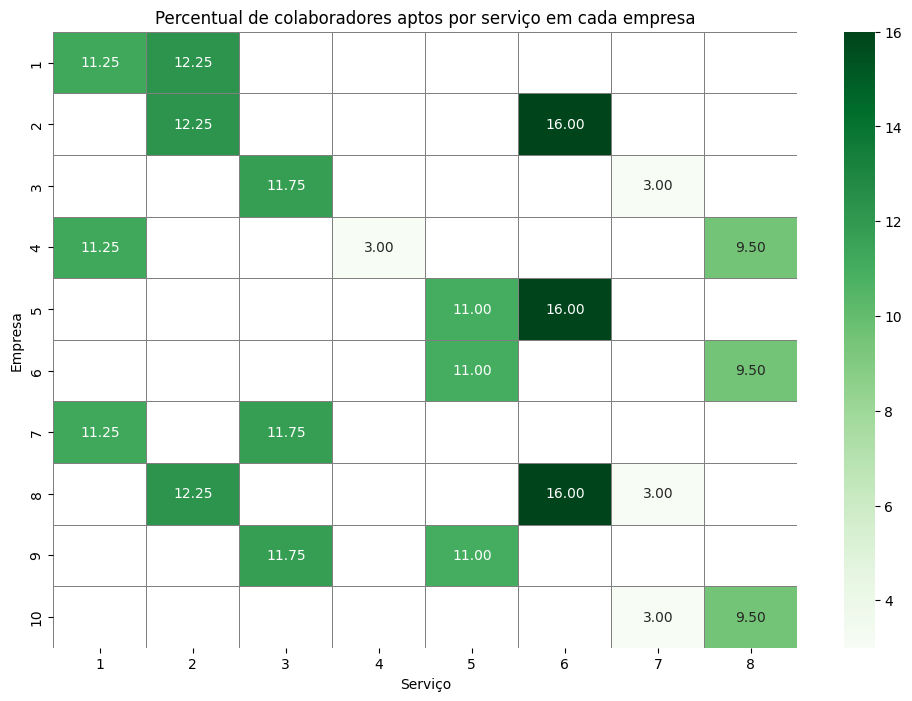

In [50]:
# Pivot para heatmap
heatmap_data = aptos_count.pivot(index='Id_Empresa', columns='Id_Servico', values='Perc_Aptos')

plt.figure(figsize=(12,8))
sns.heatmap(
    heatmap_data,
    cmap='Greens',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Percentual de colaboradores aptos por serviço em cada empresa")
plt.ylabel("Empresa")
plt.xlabel("Serviço")
plt.show()

 #Serviço 4 é o "Serviço errado" - ele existe na base assim, mas não faz sentido discutir ele aqui

In [51]:
# Merge competências de serviço/empresa com competências dos colaboradores
aptos = emp_comp.merge(colab_comp, on='Id_Competencia', how='left')

# Colaborador é apto ao serviço se ele possui a competência
aptos['Apto'] = np.where(aptos['idColaborador'].notnull(), 1, 0)

# Selecionar colunas relevantes
aptos_det = aptos[['Id_Empresa','Id_Servico','idColaborador','Apto']]

# Filtrar apenas colaboradores aptos
aptos_det = aptos_det[aptos_det['Apto'] == 1]

display(aptos_det.head())

,Id_Empresa,Id_Servico,idColaborador,Apto
0,1,1,1,1
1,1,1,4,1
2,1,1,9,1
3,1,1,14,1
4,1,1,17,1


In [52]:
aptos_list = aptos_det.groupby(['Id_Empresa','Id_Servico'])['idColaborador'].apply(list).reset_index()
display(aptos_list.head())

,Id_Empresa,Id_Servico,idColaborador
0,1,1,"[1, 4, 9, 14, 17, 21, 30, 34, 37, 43, 46, 49, ..."
1,1,2,"[2, 5, 10, 18, 21, 28, 34, 40, 44, 47, 50, 54,..."
2,2,2,"[2, 5, 10, 18, 21, 28, 34, 40, 44, 47, 50, 54,..."
3,2,6,"[2, 5, 10, 18, 21, 28, 34, 40, 44, 47, 50, 54,..."
4,3,3,"[3, 5, 11, 14, 19, 26, 30, 35, 41, 45, 48, 52,..."


In [53]:
for empresa, group in aptos_list.groupby('Id_Empresa'):
    print(f"\nEmpresa {empresa}:")
    for _, row in group.iterrows():
        print(f"  Serviço {row['Id_Servico']} → Colaboradores aptos: {row['idColaborador']}")


### FIM ###


Empresa 1:
  Serviço 1 → Colaboradores aptos: [1, 4, 9, 14, 17, 21, 30, 34, 37, 43, 46, 49, 53, 56, 61, 65, 70, 76, 80, 2, 6, 15, 24, 31, 38, 44, 47, 51, 58, 63, 69, 76, 1, 3, 13, 22, 27, 35, 45, 49, 54, 61, 71, 75, 80]
  Serviço 2 → Colaboradores aptos: [2, 5, 10, 18, 21, 28, 34, 40, 44, 47, 50, 54, 60, 63, 68, 74, 78, 1, 4, 9, 14, 17, 21, 30, 34, 37, 43, 46, 49, 53, 56, 61, 65, 70, 76, 80, 8, 10, 20, 29, 33, 42, 46, 52, 57, 62, 67, 73, 78]

Empresa 2:
  Serviço 2 → Colaboradores aptos: [2, 5, 10, 18, 21, 28, 34, 40, 44, 47, 50, 54, 60, 63, 68, 74, 78, 1, 4, 9, 14, 17, 21, 30, 34, 37, 43, 46, 49, 53, 56, 61, 65, 70, 76, 80, 8, 10, 20, 29, 33, 42, 46, 52, 57, 62, 67, 73, 78]
  Serviço 6 → Colaboradores aptos: [2, 5, 10, 18, 21, 28, 34, 40, 44, 47, 50, 54, 60, 63, 68, 74, 78, 3, 5, 11, 14, 19, 26, 30, 35, 41, 45, 48, 52, 55, 61, 67, 72, 77, 80, 4, 7, 13, 16, 20, 27, 32, 36, 42, 50, 55, 59, 63, 68, 75, 79, 8, 10, 20, 29, 33, 42, 46, 52, 57, 62, 67, 73, 78]

Empresa 3:
  Serviço 3 → Cola